In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

df = pd.read_csv("accidents_weather_ca_merged.csv")

df.head()

,Start_Lat,Start_Lng,Start_Time,Severity,lat,lon,weather_main,weather_desc,temp_f,humidity,visibility,wind_speed,rain_1h
0,38.362831,-122.267197,2016-12-09 05:25:36,2,38.362831,-122.267197,Clear,clear sky,60.03,77,10000,6.91,0
1,34.022625,-118.156616,2016-07-12 10:55:04,2,34.022625,-118.156616,Clear,clear sky,65.93,40,10000,4.61,0
2,38.254620,-122.335907,2016-06-06 11:20:16,2,38.254620,-122.335907,Clear,clear sky,60.04,76,10000,6.91,0
3,38.003071,-121.337051,2016-12-17 09:25:08,2,38.003071,-121.337051,Clear,clear sky,58.32,78,10000,9.22,0
4,37.403236,-122.046913,2016-11-04 11:01:44,2,37.403236,-122.046913,Clear,clear sky,60.51,72,10000,8.05,0


In [ ]:
labels = df["Severity"]

df_no_label = df.drop(columns=["Severity"])

df_no_label.head()

,Start_Lat,Start_Lng,Start_Time,lat,lon,weather_main,weather_desc,temp_f,humidity,visibility,wind_speed,rain_1h
0,38.362831,-122.267197,2016-12-09 05:25:36,38.362831,-122.267197,Clear,clear sky,60.03,77,10000,6.91,0
1,34.022625,-118.156616,2016-07-12 10:55:04,34.022625,-118.156616,Clear,clear sky,65.93,40,10000,4.61,0
2,38.254620,-122.335907,2016-06-06 11:20:16,38.254620,-122.335907,Clear,clear sky,60.04,76,10000,6.91,0
3,38.003071,-121.337051,2016-12-17 09:25:08,38.003071,-121.337051,Clear,clear sky,58.32,78,10000,9.22,0
4,37.403236,-122.046913,2016-11-04 11:01:44,37.403236,-122.046913,Clear,clear sky,60.51,72,10000,8.05,0


In [ ]:
X = df_no_label[[
    "temp_f",
    "humidity",
    "visibility",
    "wind_speed"
]].copy()

X.head()

,temp_f,humidity,visibility,wind_speed
0,60.03,77,10000,6.91
1,65.93,40,10000,4.61
2,60.04,76,10000,6.91
3,58.32,78,10000,9.22
4,60.51,72,10000,8.05


In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

X_scaled_df.head()

,temp_f,humidity,visibility,wind_speed
0,0.175436,0.556004,0.0,-0.152041
1,2.099294,-2.345569,0.0,-0.796375
2,0.178697,0.477583,0.0,-0.152041
3,-0.382156,0.634425,0.0,0.495096
4,0.331954,0.163900,0.0,0.167325


In [5]:
print("Means after scaling:")
print(X_scaled_df.mean())

print("\nStandard deviations after scaling:")
print(X_scaled_df.std())

Means after scaling:
temp_f        6.217249e-16
humidity      2.735590e-16
visibility    0.000000e+00
wind_speed    2.522427e-16
dtype: float64

Standard deviations after scaling:
temp_f        1.001002
humidity      1.001002
visibility    0.000000
wind_speed    1.001002
dtype: float64


In [6]:
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_scaled)

print("Explained Variance Ratio (3D):")
print(pca.explained_variance_ratio_)

print("\nCumulative Variance (3D):")
print(np.cumsum(pca.explained_variance_ratio_))

Explained Variance Ratio (3D):
[0.55758766 0.32943362 0.11297872]

Cumulative Variance (3D):
[0.55758766 0.88702128 1.        ]


In [7]:
X_pca_df = pd.DataFrame(X_pca, columns=["PC1", "PC2", "PC3"])
X_pca_df.head()

,PC1,PC2,PC3
0,0.238798,-0.108239,0.542489
1,-3.244620,-0.084738,-0.090574
2,0.181412,-0.105254,0.489026
3,0.815683,0.344664,0.097600
4,-0.070483,0.253019,0.309947


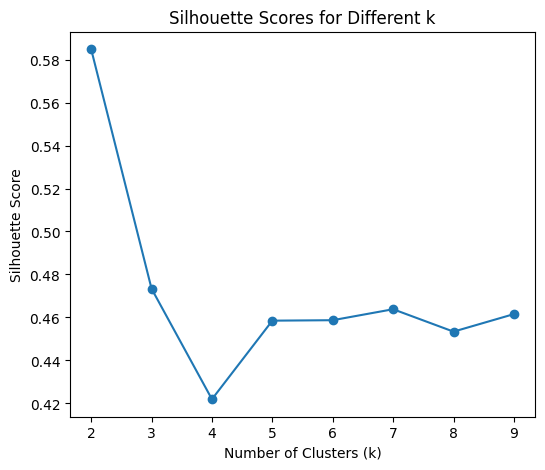

In [8]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

sil_scores = []
K_range = range(2, 10)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    cluster_labels = kmeans.fit_predict(X_pca)
    score = silhouette_score(X_pca, cluster_labels)
    sil_scores.append(score)

plt.figure(figsize=(6,5))
plt.plot(K_range, sil_scores, marker='o')
plt.title("Silhouette Scores for Different k")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.show()

In [9]:
for k, score in zip(K_range, sil_scores):
    print(f"k = {k}, Silhouette Score = {score:.4f}")

k = 2, Silhouette Score = 0.5848
k = 3, Silhouette Score = 0.4734
k = 4, Silhouette Score = 0.4220
k = 5, Silhouette Score = 0.4585
k = 6, Silhouette Score = 0.4587
k = 7, Silhouette Score = 0.4638
k = 8, Silhouette Score = 0.4534
k = 9, Silhouette Score = 0.4616


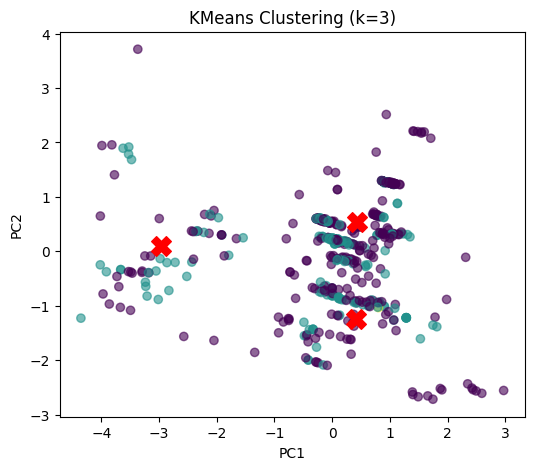

In [10]:
k = 3
kmeans = KMeans(n_clusters=k, random_state=42)
clusters = kmeans.fit_predict(X_pca)

plt.figure(figsize=(6,5))
plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=labels,
    cmap='viridis',
    alpha=0.6
)

centroids = kmeans.cluster_centers_
plt.scatter(
    centroids[:,0],
    centroids[:,1],
    c='red',
    marker='X',
    s=200
)

plt.title(f"KMeans Clustering (k={k})")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

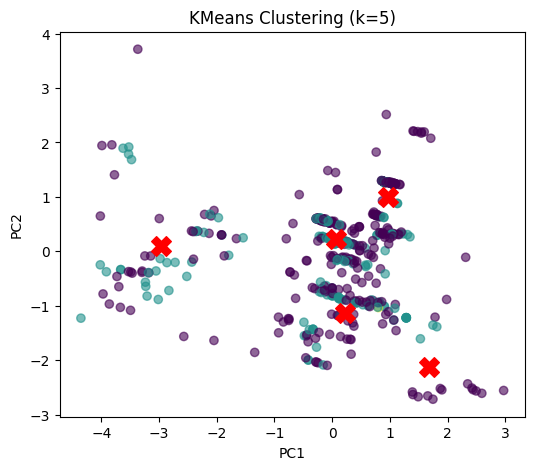

In [11]:
k = 5
kmeans = KMeans(n_clusters=k, random_state=42)
clusters = kmeans.fit_predict(X_pca)

plt.figure(figsize=(6,5))
plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=labels,
    cmap='viridis',
    alpha=0.6
)

centroids = kmeans.cluster_centers_
plt.scatter(
    centroids[:,0],
    centroids[:,1],
    c='red',
    marker='X',
    s=200
)

plt.title(f"KMeans Clustering (k={k})")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

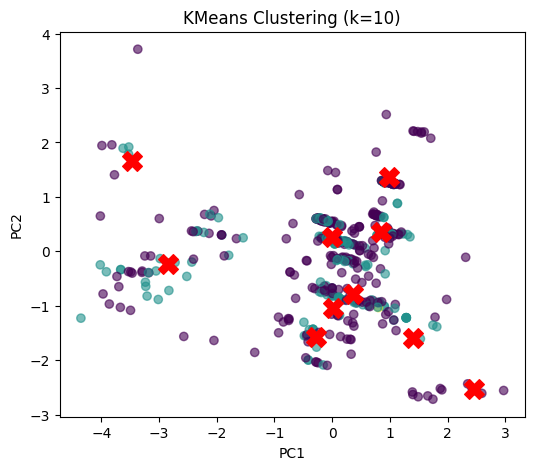

In [12]:
k = 10
kmeans = KMeans(n_clusters=k, random_state=42)
clusters = kmeans.fit_predict(X_pca)

plt.figure(figsize=(6,5))
plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=labels,
    cmap='viridis',
    alpha=0.6
)

centroids = kmeans.cluster_centers_
plt.scatter(
    centroids[:,0],
    centroids[:,1],
    c='red',
    marker='X',
    s=200
)

plt.title(f"KMeans Clustering (k={k})")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

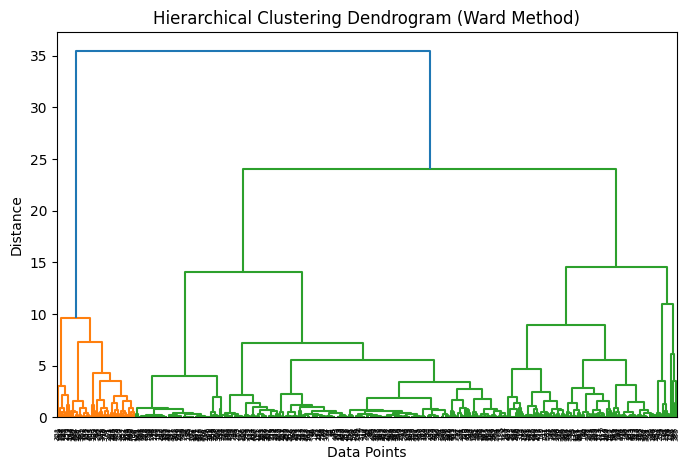

In [13]:
from scipy.cluster.hierarchy import dendrogram, linkage

linked = linkage(X_pca, method='ward')

plt.figure(figsize=(8,5))
dendrogram(linked)
plt.title("Hierarchical Clustering Dendrogram (Ward Method)")
plt.xlabel("Data Points")
plt.ylabel("Distance")
plt.show()

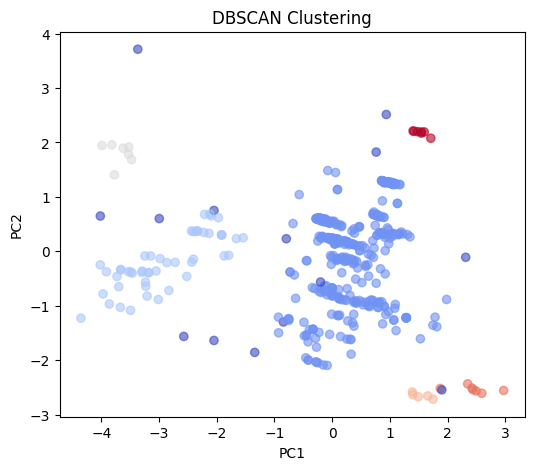

In [14]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=0.8, min_samples=5)
db_clusters = dbscan.fit_predict(X_pca)

plt.figure(figsize=(6,5))
plt.scatter(X_pca[:,0], X_pca[:,1], c=db_clusters, cmap='coolwarm', alpha=0.6)
plt.title("DBSCAN Clustering")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

In [15]:
print("Unique DBSCAN cluster labels:")
print(set(db_clusters))

print("Number of noise points (-1):")
print(sum(db_clusters == -1))

Unique DBSCAN cluster labels:
{np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(-1)}
Number of noise points (-1):
14
